<a href="https://colab.research.google.com/github/RicardoCastelhano/Transfer-learning-fine-tuning/blob/main/transfer_learning_dio_rev1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer learning / fine-tuning

Este Colab implementa uma solução de Transfer Learning (Aprendizado por Transferência) para classificar imagens como Gato ou Cachorro. Em vez de treinar uma rede neural do zero, utilizamos o conhecimento prévio de um modelo avançado (VGG16), adaptando-o para a nossa tarefa binária específica.

1. Configuração e Dependências (Bloco 1 e Início do Bloco 2)AçãoDescriçãoImportsImporta bibliotecas essenciais como Keras, NumPy, Matplotlib e funções específicas para pré-processamento de imagens (preprocess_input).Instalação do wgetGarante que o pacote wget (necessário para baixar arquivos da internet) esteja disponível no ambiente do Colab.

2. Carregamento e Preparação dos Dados (Blocos 2 e 3)
Esta seção garante que os dados de Gato e Cachorro sejam baixados e processados de forma eficiente usando os Generators do Keras, que evitam carregar todas as 2.000 imagens na memória de uma vez.

3. Construção do Modelo de Transfer Learning (Bloco 4)
Aqui, adaptamos o modelo VGG16, que é a essência do Transfer Learning.

4. Treinamento e Avaliação (Blocos 5, 7 e 8)

5. Teste Manual (Bloco 9)
Este bloco finaliza o projeto com um teste qualitativo em imagens novas.


In [ ]:
# --- Bloco 1: importar bibliotecas ---

%matplotlib inline

!pip install wget

import os

#if using Theano with GPU
#os.environ["KERAS_BACKEND"] = "tensorflow"

import random
import numpy as np
import keras
import zipfile
import wget

import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

from keras.preprocessing import image
from keras.applications.imagenet_utils import preprocess_input
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Activation
from keras.layers import Conv2D, MaxPooling2D
from keras.models import Model

In [ ]:
# --- Bloco 2: Download do Dataset Cats vs. Dogs ---

print("Downloading Cats vs. Dogs dataset (Filtered version for efficiency)")

# Caminho e URL do dataset
DATASET_URL = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'
ZIP_FILE = 'cats_and_dogs_filtered.zip'
BASE_DIR = 'cats_and_dogs_filtered'

# Baixa e descompacta o arquivo (se já não estiver lá)
if not os.path.exists(BASE_DIR):
    !wget -q $DATASET_URL
    with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
        zip_ref.extractall()
    !rm $ZIP_FILE

# Define os diretórios de treino e validação
train_dir = os.path.join(BASE_DIR, 'train')
validation_dir = os.path.join(BASE_DIR, 'validation')

print(f"Dataset pronto! Diretório de Treino: {train_dir}")
print(f"Diretório de Validação: {validation_dir}")


Dataset pronto! Diretório de Treino: cats_and_dogs_filtered/train
Diretório de Validação: cats_and_dogs_filtered/validation


In [ ]:
# --- Bloco 3: ImageDataGenerator (Carregamento e Data Augmentation) ---

# Importação CORRIGIDA para o caminho atual do TensorFlow Keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications.imagenet_utils import preprocess_input # Importada no Bloco 1

IMG_SIZE = 224 # Tamanho da imagem que o VGG16 (modelo base) espera
BATCH_SIZE = 32
NUM_CLASSES = 2 # Gato e Cachorro

# 1. Configurar o Data Augmentation para Treinamento
train_datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=preprocess_input
)

# 2. Configurar o Pré-processamento para Validação (apenas o necessário)
validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# 3. Criar os Geradores de Dados
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary' # 'binary' para 2 classes
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print(f"\nNúmero de classes: {NUM_CLASSES}")
print(f"Mapeamento de Classes: {train_generator.class_indices}")

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.

Número de classes: 2
Mapeamento de Classes: {'cats': 0, 'dogs': 1}


In [ ]:
# --- Bloco 4: Construção do Modelo de Transfer Learning (VGG16) ---
from keras.applications import VGG16
from keras.layers import GlobalAveragePooling2D, Dense, Dropout
from keras.models import Model
import os

# Variáveis globais definidas no Bloco 3
IMG_SIZE = 224 # Tamanho esperado pelo modelo base

# 1. Carregar o modelo base VGG16
# include_top=False: remove as camadas finais de classificação originais
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# 2. Congelar as camadas do modelo base
for layer in base_model.layers:
    layer.trainable = False

# 3. Construir o novo classificador (o 'topo')
x = base_model.output
x = GlobalAveragePooling2D()(x) # Converte a saída em um vetor (512 elementos)
x = Dense(256, activation='relu')(x) # Camada densa intermediária
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x) # Camada de saída: 1 neurônio com 'sigmoid' para classificação BINÁRIA

# 4. Definir o modelo final
model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compilar o modelo
# loss='binary_crossentropy' é crucial para a saída Sigmoid (classificação binária)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [5]:
# --- Bloco 5: Treinamento do Modelo (Usando Generators) ---

# Variáveis globais definidas no Bloco 3
BATCH_SIZE = 32
EPOCHS = 10

# O número de passos (batches) por época é essencial ao usar generators
steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = validation_generator.samples // BATCH_SIZE

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_steps
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1684s 27s/step - accuracy: 0.8038 - loss: 0.8697 - val_accuracy: 0.9798 - val_loss: 0.0818
Epoch 2/10
 1/62 ━━━━━━━━━━━━━━━━━━━━ 17:39 17s/step - accuracy: 0.9062 - loss: 0.1479

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


62/62 ━━━━━━━━━━━━━━━━━━━━ 570s 9s/step - accuracy: 0.9062 - loss: 0.1479 - val_accuracy: 0.9798 - val_loss: 0.0752
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1701s 28s/step - accuracy: 0.9583 - loss: 0.1376 - val_accuracy: 0.9768 - val_loss: 0.0810
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 615s 10s/step - accuracy: 1.0000 - loss: 0.0391 - val_accuracy: 0.9758 - val_loss: 0.0835
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1704s 28s/step - accuracy: 0.9644 - loss: 0.1157 - val_accuracy: 0.9758 - val_loss: 0.0752
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 622s 10s/step - accuracy: 0.9375 - loss: 0.0689 - val_accuracy: 0.9768 - val_loss: 0.0687
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1701s 27s/step - accuracy: 0.9640 - loss: 0.0936 - val_accuracy: 0.9808 - val_loss: 0.0565
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 561s 9s/step - accuracy: 1.0000 - loss: 0.0191 - val_accuracy: 0.9798 - val_loss: 0.0566
Epoch 9/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1669s 27s/step - accuracy: 0.9659 - loss: 0.0803 - val_accuracy: 0.9798 - va

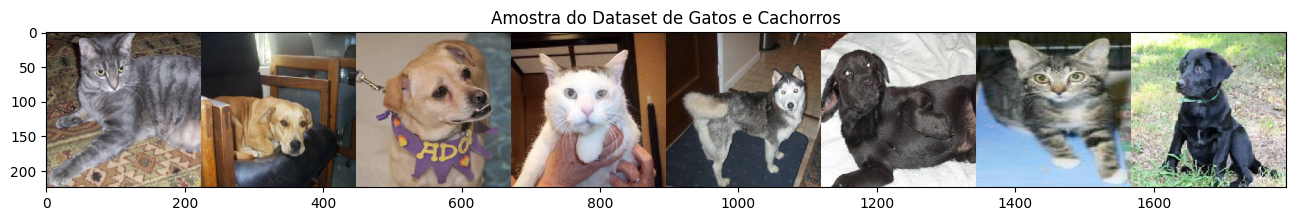

In [6]:
# --- Bloco 6: Visualização de Imagens ---
import matplotlib.pyplot as plt
from keras.preprocessing import image
import random
import glob
import numpy as np

# Variáveis globais definidas no Bloco 2
train_dir = 'cats_and_dogs_filtered/train'

# Encontra todas as imagens de treino (Gato e Cachorro)
image_paths = glob.glob(os.path.join(train_dir, '*', '*.jpg'))

# Seleciona 8 índices aleatórios
idx = [int(len(image_paths) * random.random()) for i in range(8)]
imgs = [image.load_img(image_paths[i], target_size=(224, 224)) for i in idx]

# Concatena e exibe
concat_image = np.concatenate([np.asarray(img) for img in imgs], axis=1)
plt.figure(figsize=(16,4))
plt.imshow(concat_image)
plt.title("Amostra do Dataset de Gatos e Cachorros")
plt.show()

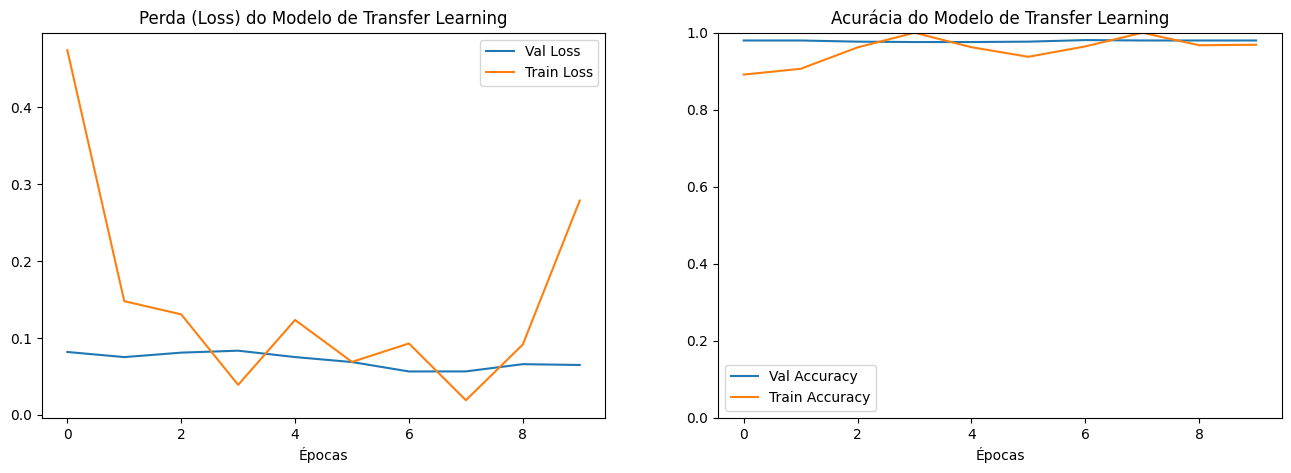

In [7]:
# --- Bloco 7: Plotagem das Curvas de Treinamento ---

# As chaves de métricas são 'accuracy' e 'val_accuracy' no fluxo moderno do Keras
fig = plt.figure(figsize=(16,5))
ax = fig.add_subplot(121)
ax.plot(history.history["val_loss"], label="Val Loss")
ax.plot(history.history["loss"], label="Train Loss")
ax.set_title("Perda (Loss) do Modelo de Transfer Learning")
ax.set_xlabel("Épocas")
ax.legend()

ax2 = fig.add_subplot(122)
ax2.plot(history.history["val_accuracy"], label="Val Accuracy")
ax2.plot(history.history["accuracy"], label="Train Accuracy")
ax2.set_title("Acurácia do Modelo de Transfer Learning")
ax2.set_xlabel("Épocas")
ax2.set_ylim(0, 1)
ax2.legend()

plt.show()

In [8]:
# --- Bloco 8: Avaliação Final ---

# Variáveis globais definidas no Bloco 3
BATCH_SIZE = 32

# Avalia o modelo no conjunto de validação/teste
loss, accuracy = model.evaluate(validation_generator,
                                steps=validation_generator.samples // BATCH_SIZE,
                                verbose=1)

print('\nAvaliação Final no Conjunto de Validação:')
print(f'Test loss: {loss:.4f}')
print(f'Test accuracy: {accuracy:.4f}')

31/31 ━━━━━━━━━━━━━━━━━━━━ 545s 18s/step - accuracy: 0.9790 - loss: 0.0611

Avaliação Final no Conjunto de Validação:
Test loss: 0.0648
Test accuracy: 0.9798


Testando 10 imagens (5 Gatos e 5 Cachorros)...


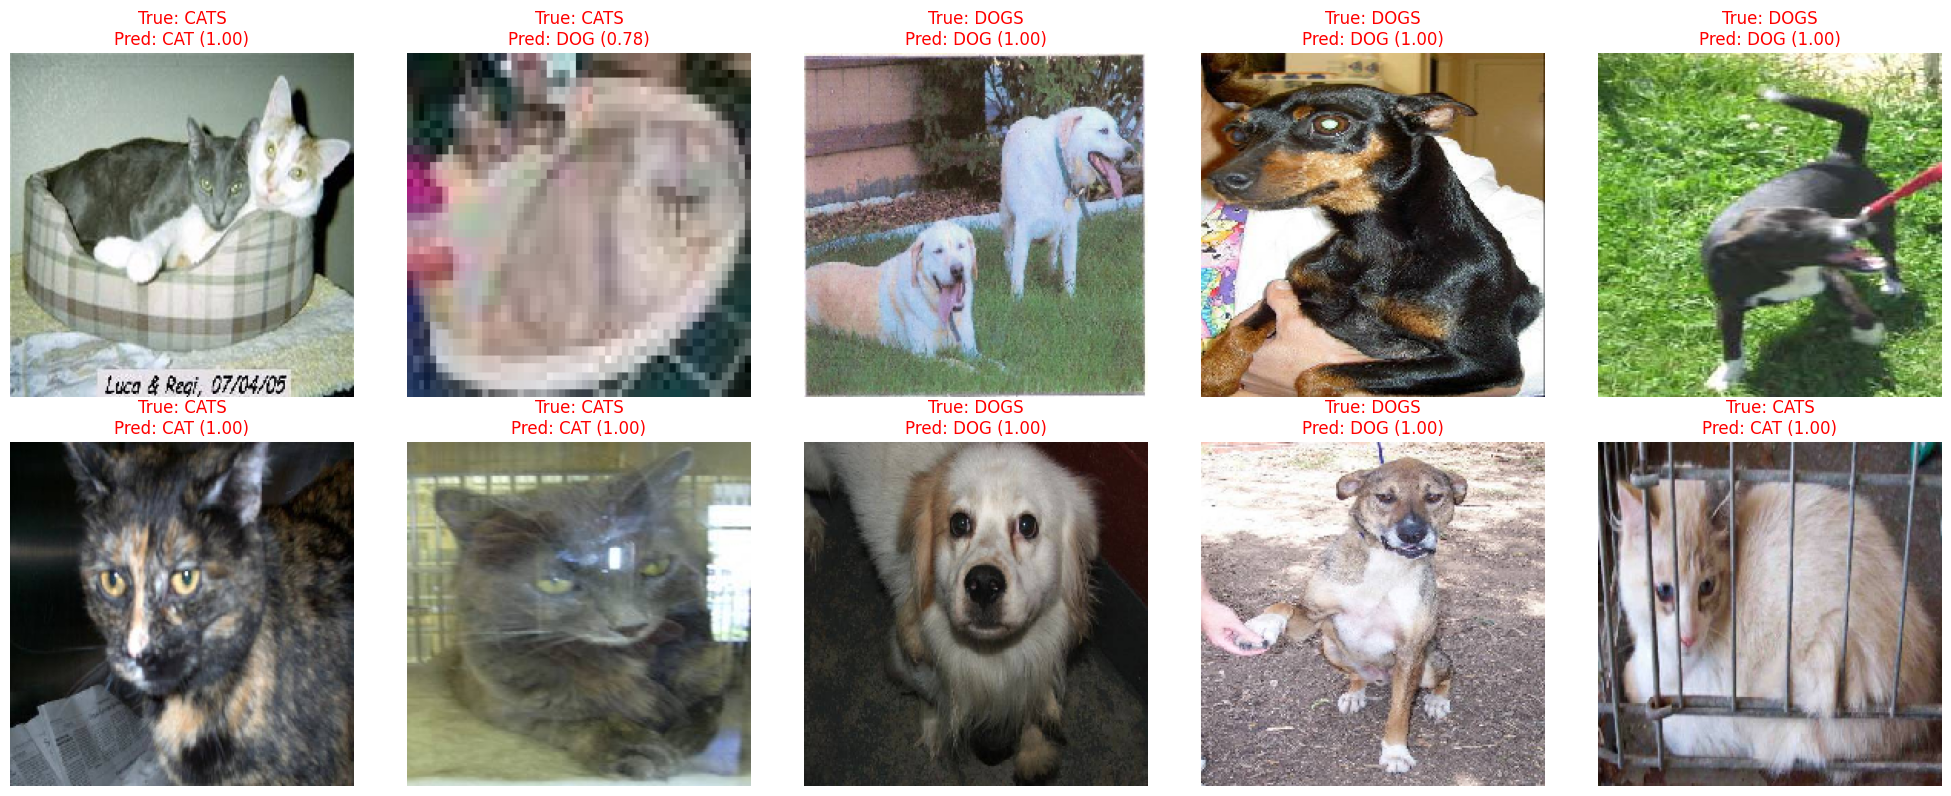

In [9]:
# --- Bloco 9: Teste com 5 Gatos e 5 Cachorros (Ajuste Final Completo) ---

# Importações e Definição da função get_image (Corrigindo o NameError)
from keras.preprocessing import image
from keras.applications.imagenet_utils import preprocess_input
import os
import matplotlib.pyplot as plt
import numpy as np
import random # Necessário para selecionar imagens aleatoriamente

# A função get_image DEVE estar definida
def get_image(path):
    # Carrega a imagem e redimensiona para o formato do VGG16
    img = image.load_img(path, target_size=(224, 224))
    x = image.img_to_array(img)
    # Adiciona a dimensão do batch
    x = np.expand_dims(x, axis=0)
    # Aplica o pré-processamento do ImageNet
    x = preprocess_input(x)
    return img, x


# Variáveis globais definidas no Bloco 2
validation_dir = 'cats_and_dogs_filtered/validation'
NUM_SAMPLES = 5 # Quantidade de amostras por classe

# 1. Obter 5 caminhos de Gatos e 5 de Cachorros
cat_dir = os.path.join(validation_dir, 'cats')
dog_dir = os.path.join(validation_dir, 'dogs')

# Lista todos os arquivos e seleciona aleatoriamente
cat_files = os.listdir(cat_dir)
dog_files = os.listdir(dog_dir)

random.shuffle(cat_files)
random.shuffle(dog_files)

test_files = [os.path.join(cat_dir, f) for f in cat_files[:NUM_SAMPLES]]
test_files += [os.path.join(dog_dir, f) for f in dog_files[:NUM_SAMPLES]]
random.shuffle(test_files) # Mistura a ordem para um teste mais justo

# 2. Configurar a figura para exibir os 10 resultados
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

print(f"Testando {len(test_files)} imagens (5 Gatos e 5 Cachorros)...")

# 3. Fazer predições e exibir
for i, test_image_path in enumerate(test_files):
    # Carrega e pré-processa
    img, x = get_image(test_image_path)

    # Prediz
    probabilities = model.predict(x, verbose=0)

    # Interpreta o resultado
    predicted_value = probabilities[0][0] # Valor entre 0 e 1
    predicted_class = "DOG" if predicted_value > 0.5 else "CAT"
    confidence = predicted_value if predicted_class == "DOG" else 1 - predicted_value

    # Obtém a classe verdadeira para o título
    true_class = os.path.basename(os.path.dirname(test_image_path)).upper()

    # Exibe no subplot
    axes[i].imshow(img)
    axes[i].set_title(f"True: {true_class}\nPred: {predicted_class} ({confidence:.2f})",
                      color=('green' if predicted_class == true_class else 'red'))
    axes[i].axis('off')

plt.tight_layout()
plt.show()